## Data Preprocessing

In this notebook, we will perform data preprocessing tasks necessary for our CaloriFy project. This includes loading the dataset, cleaning it, and preparing it for training our models.

> Purpose:

- Loads and explores the .h5 dataset (food_c101_n1000_r384x384x3.h5)

- Performs EDA: shape, label formats, visual samples, missing data

- Optional: transforms, normalizes, saves processed subsets if needed

> Helps you:

- Understand the dataset structure (images, multi-labels)

- Prepare data for modeling

- Identify problems (imbalances, noisy images, etc.)

In [15]:
# IMPORT NECESSARY LIBRARIES
import h5py
import numpy as np
#import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# STEP 1: LOAD THE DATASET (FILE AND KEYS)
food101_data_path = "../data/preprocessed/food_c101_n1000_r384x384x3.h5"
food101File = h5py.File(food101_data_path, 'r')

print("Keys in HDF5 (FOOD101 DATASET) File: ", list(food101File.keys()))

Keys in HDF5 (FOOD101 DATASET) File:  ['category', 'category_names', 'images']


In [53]:
# STEP 2: EXTRACT AND INSPECT ARAYS FROM THE DATASET

images = food101File['images']
print("Images Shape: ", images.shape)
print("Images Dtype: ", images.dtype)
print()

categories = food101File['category']
print("Categories shape:", categories.shape)
print("Category dtype:", categories.dtype)
print("Sample labels:", categories[:10])
print()

category_names = food101File['category_names']
print("Number of classes:", len(category_names))
print("Sample class names:", [name.decode() for name in category_names[:5]])
print()

#category_names_list = [name.decode() for name in category_names[:]]
label_map = {i: name.decode() for i, name in enumerate(category_names[:])}
print()


Images Shape:  (1000, 384, 384, 3)
Images Dtype:  uint8

Categories shape: (1000, 101)
Category dtype: bool
Sample labels: [[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]

Number of classes: 101
Sample class names: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']




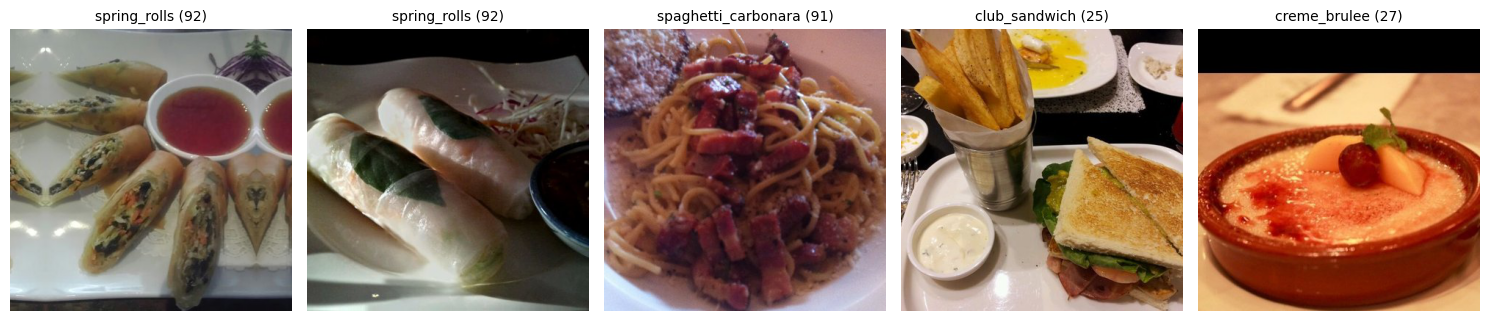

In [52]:
# STEP 3: VISUALIZE SAMPLE IMAGES AND LABELS

def plot_sample_images(images, categories, label_map, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        idx = np.random.randint(0, len(images))
        img = images[idx]
        label = np.argmax(np.array(categories[idx]))
        class_name = label_map[label]

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img.astype('uint8'))
        plt.title(f"{class_name} ({label})", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(images, categories, label_map, num_samples=5)

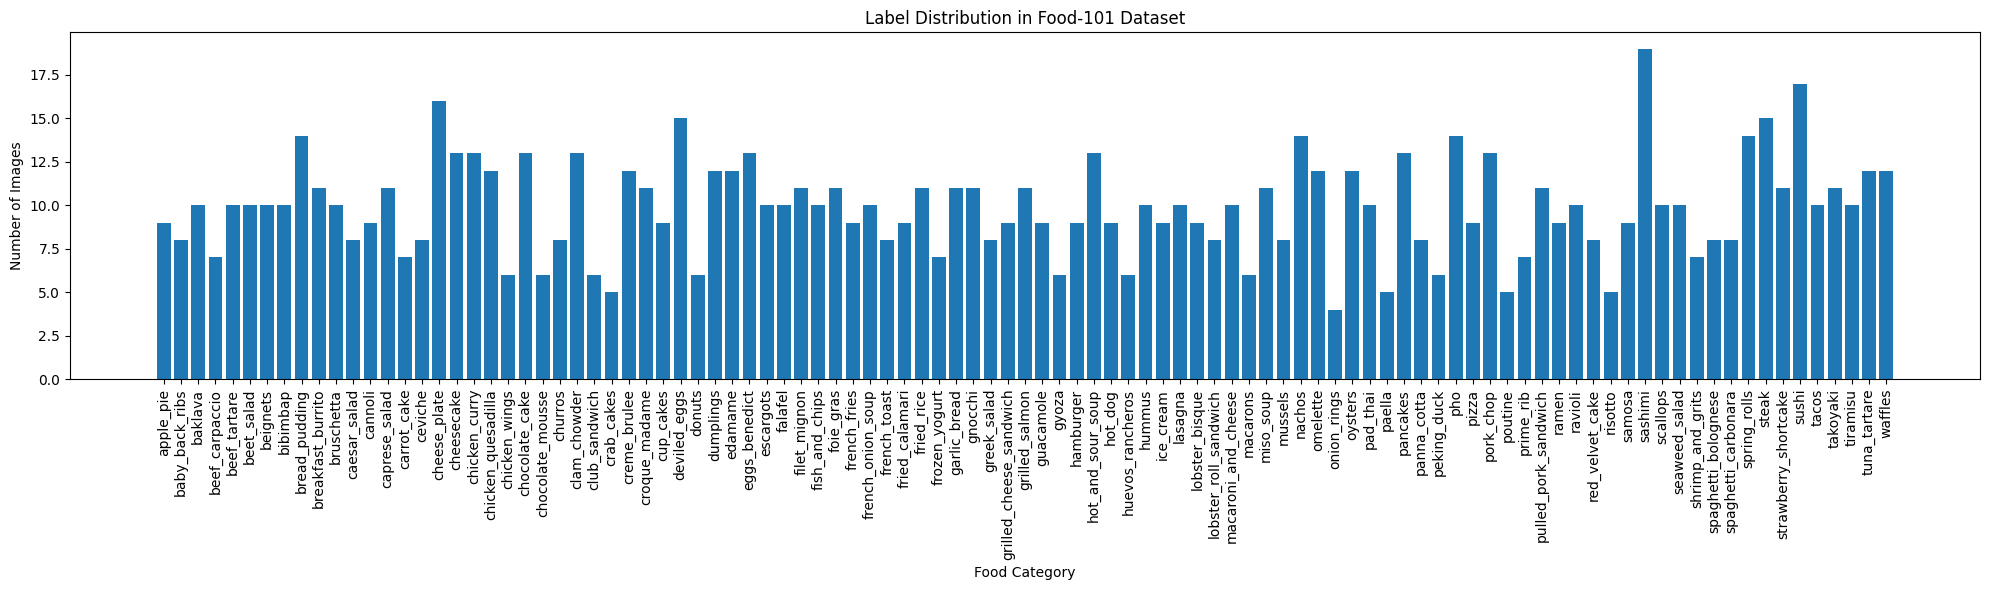

In [ ]:
# STEP 4: UNDERSTAND THE LABEL DISTRIBUTION

from collections import Counter

# Convert all one-hot vectors to class indices
label_indices = [np.argmax(np.array(cat)) for cat in categories]

# Count frequency of each class
label_counts = Counter(label_indices)

# Convert to list for plotting
sorted_labels = sorted(label_counts.keys())
frequencies = [label_counts[label] for label in sorted_labels]
class_names = [label_map[label] for label in sorted_labels]

# Plot the distribution
plt.figure(figsize=(20, 6))
plt.bar(class_names, frequencies)
plt.xticks(rotation=90)
plt.title("Label Distribution in Food-101 Dataset")
plt.xlabel("Food Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we have successfully loaded the raw images, preprocessed them, and saved the processed images for further use in our models. Next, we can move on to food classification and calorie regression tasks.